In [3]:
import os
import nibabel as nib
import numpy as np 
from collections import OrderedDict
import json
from pathlib import Path

from utils.helper import convert_nrrd_to_nifti, create_folder, plot_all_slices, plot_histogram, generate_binary_image, adjust_affine_for_spacing_and_origin, save_binary_image_with_adjusted_origin, make_if_dont_exist

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

def save_and_plot_roi_masks(roi_image_path, output_dir, slice_index):
    # Ensure the output directory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Load the ROI mask 3D image
    roi_img = nib.load(roi_image_path)
    roi_data = roi_img.get_fdata()
    
    slice_index = roi_img.shape[2] // 2

    # Find unique region identifiers, ignoring the background (0)
    regions = np.unique(roi_data)[1:]  # Skip the first element as it's 0 (background)
    
    # Placeholder for combined 2D view of all regions
    combined_slice = np.zeros_like(roi_data[:,:,slice_index])
    
    # Process each region
    for region in regions:
        # Create a mask for the current region
        region_mask = np.where(roi_data == region, 1, 0)
        
        # Save the mask as a new NIfTI image
        region_img = nib.Nifti1Image(region_mask, roi_img.affine, roi_img.header)
        # nib.save(region_img, os.path.join(output_dir, f'region_{int(region)}.nii.gz'))
        
        # Update the combined slice for 2D visualization
        combined_slice += (region_mask[:,:,slice_index] * region)
    
    # Plotting the combined 2D view of all regions
    plt.imshow(combined_slice, cmap='tab20', interpolation='nearest')
    plt.title(f'Combined 2D view of all regions, Slice: {slice_index}')
    # plt.colorbar()
    plt.axis('off')
    plt.show()

In [12]:
source_nrrd_file_path = "/work/shared/ngmm/3Dimage/Analysed_brains/Zbtb20/NG2566_Segments_Elo2.nrrd"
base_name = os.path.splitext(os.path.basename(source_nrrd_file_path))[0]
save_nifti_file_path = os.path.join("/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/data", base_name + '_0000.nii.gz')

convert_nrrd_to_nifti(source_nrrd_file_path, save_nifti_file_path)

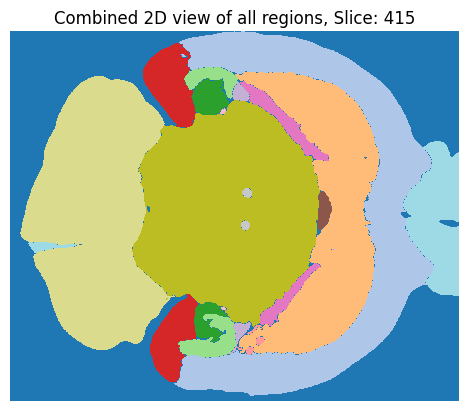

In [2]:
# Example usage
roi_image_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/data/NG2566_Segments_Elo2_0000.nii.gz'
output_dir = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/individual_regions/NG2564'
slice_index = 201  # Change this based on which slice you want to visualize
save_and_plot_roi_masks(roi_image_path, output_dir, slice_index)


In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path = "/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/data/NG2566_Segments_Elo2_0000.nii.gz"
nifti_path = "dataset/individual_regions/NG4117/8_ig.nii.gz"
# org_nifti_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset003_HPC/imagesTr/NG4115_RCL5_0000.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()

# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    
    # Display the slice
    ax = axes[0,0]
    ax.imshow(data[:, :, slice_no], cmap='tab20', interpolation='nearest')
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    # Display the histogram
    ax = axes[0,1]
    slice_data = data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Pixel Intensity Distribution')
    ax.grid(True)

    ax = axes[1,0]
    ax.imshow(data[:, slice_no,: ].T, cmap='tab20', interpolation='nearest')
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')

    ax = axes[1,1]
    ax.imshow(data[slice_no, :,: ], cmap='tab20', interpolation='nearest')
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    plt.tight_layout()
    plt.show()

def display_slice(slice_no):
    plt.imshow(data[:,:,slice_no], cmap='tab20', interpolation='nearest')  
    plt.title(f"Slice {slice_no}")
    plt.colorbar()
    plt.axis('off')  # Turn off axis
    plt.show()



In [7]:
# Interactive widget for slice selection
slice_slider = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice'
)

widgets.interactive(display_slice_and_histogram, slice_no=slice_slider)

interactive(children=(IntSlider(value=198, description='Slice', max=395), Output()), _dom_classes=('widget-int…

In [8]:
def display_slice(slice_no):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    # First plot with interpolation
    axs[0].imshow(data[:, :, slice_no], cmap='tab20', interpolation='nearest')
    axs[0].set_title(f"Slice {slice_no} - Interpolation")
    axs[0].axis('off')
    
    # Second plot with a gray colormap
    axs[1].imshow(data[:, :, slice_no], cmap='gray', interpolation='none')
    axs[1].set_title(f"Slice {slice_no} - Colormap: gray")
    axs[1].axis('off')
    
    # plt.colorbar(axs[0].imshow(data[:, :, slice_no], cmap='tab20', interpolation='nearest'), ax=axs[0], orientation='vertical')
    # plt.colorbar(axs[1].imshow(data[:, :, slice_no], cmap='gray', interpolation='none'), ax=axs[1], orientation='vertical')
    
    plt.show()


widgets.interactive(display_slice, slice_no=slice_slider)

interactive(children=(IntSlider(value=198, description='Slice', max=395), Output()), _dom_classes=('widget-int…

In [3]:
from utils.helper import read_and_display_json
lable_json_path = "/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/dataset.json"
data = read_and_display_json(lable_json_path)
labels =  data.get('labels', {})
swapped_dict = {value: key for key, value in labels.items()}
swapped_dict

{0: 'background',
 1: 'CTX+',
 2: 'cc+',
 3: 'CPu',
 4: 'DG',
 5: 'HP',
 6: 'RHP',
 7: 'A',
 8: 'ig',
 9: 'fi',
 10: 'f',
 11: 'st',
 12: 'ic',
 13: 'och',
 14: 'ac',
 15: 'fr',
 16: 'Hb',
 17: 'TH',
 18: 'HY',
 19: 'MB',
 20: 'P',
 21: 'MY',
 22: 'TCB',
 23: 'V',
 24: 'OB'}

In [2]:
import nibabel as nib
import numpy as np
import os
import matplotlib.pyplot as plt

# Load the original NIfTI volume
nifti_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset001_Wdr47Kusss/imagesTr/Wdr47Kusss_NG_2603_0000.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()
affine = img.affine
print(img.shape)

(634, 782, 354)


In [9]:
import nibabel as nib
import numpy as np
import os
import matplotlib.pyplot as plt

# Load the original NIfTI volume
nifti_path = '/work/shared/ngmm/3Dimage/DL_test/source_backgroundremoval/28-05-2024/NG4126_RCL5.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()
affine = img.affine
header = img.header

# Create output directory if it doesn't exist
output_dir = 'dataset/individual_regions/NG4117'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


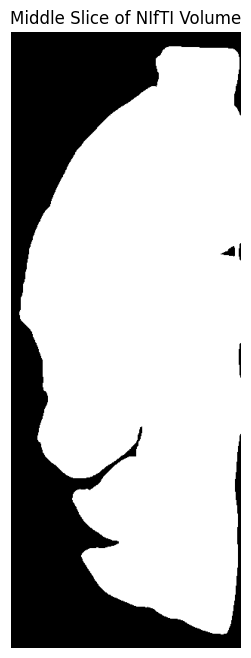

In [10]:

# Extract a middle slice for display (adjust as needed)
middle_slice = data[:, :, data.shape[2] // 2]

# Display the slice
plt.figure(figsize=(10, 8))
plt.imshow(middle_slice.T, cmap='gray', origin='lower')
plt.title('Middle Slice of NIfTI Volume')
plt.axis('off')
plt.show()

In [37]:
# Get the unique values in the volume
unique_values = np.unique(data)

# Print the unique values
print("Unique values in the volume:", unique_values)
print("Total Unique values in the volume:", len(unique_values))

Unique values in the volume: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24.]
Total Unique values in the volume: 25


In [38]:

# Save each region into a separate NIfTI file
for region_label in range(1, 25): 
    region_data = np.zeros_like(data)
    region_data[data == region_label] = region_label
    
    # Create a new NIfTI image for the region
    region_img = nib.Nifti1Image(region_data, affine, header)
    
    # Define the output file path
    output_file = os.path.join(output_dir, f'{region_label}_{swapped_dict[region_label]}.nii.gz')
    
    # Save the region NIfTI file
    nib.save(region_img, output_file)
    print(f'Saved region {region_label} to {output_file}')


Saved region 1 to dataset/individual_regions/NG4117/1_CTX+.nii.gz
Saved region 2 to dataset/individual_regions/NG4117/2_cc+.nii.gz
Saved region 3 to dataset/individual_regions/NG4117/3_CPu.nii.gz
Saved region 4 to dataset/individual_regions/NG4117/4_DG.nii.gz
Saved region 5 to dataset/individual_regions/NG4117/5_HP.nii.gz
Saved region 6 to dataset/individual_regions/NG4117/6_RHP.nii.gz
Saved region 7 to dataset/individual_regions/NG4117/7_A.nii.gz
Saved region 8 to dataset/individual_regions/NG4117/8_ig.nii.gz
Saved region 9 to dataset/individual_regions/NG4117/9_fi.nii.gz
Saved region 10 to dataset/individual_regions/NG4117/10_f.nii.gz
Saved region 11 to dataset/individual_regions/NG4117/11_st.nii.gz
Saved region 12 to dataset/individual_regions/NG4117/12_ic.nii.gz
Saved region 13 to dataset/individual_regions/NG4117/13_och.nii.gz
Saved region 14 to dataset/individual_regions/NG4117/14_ac.nii.gz
Saved region 15 to dataset/individual_regions/NG4117/15_fr.nii.gz
Saved region 16 to datas

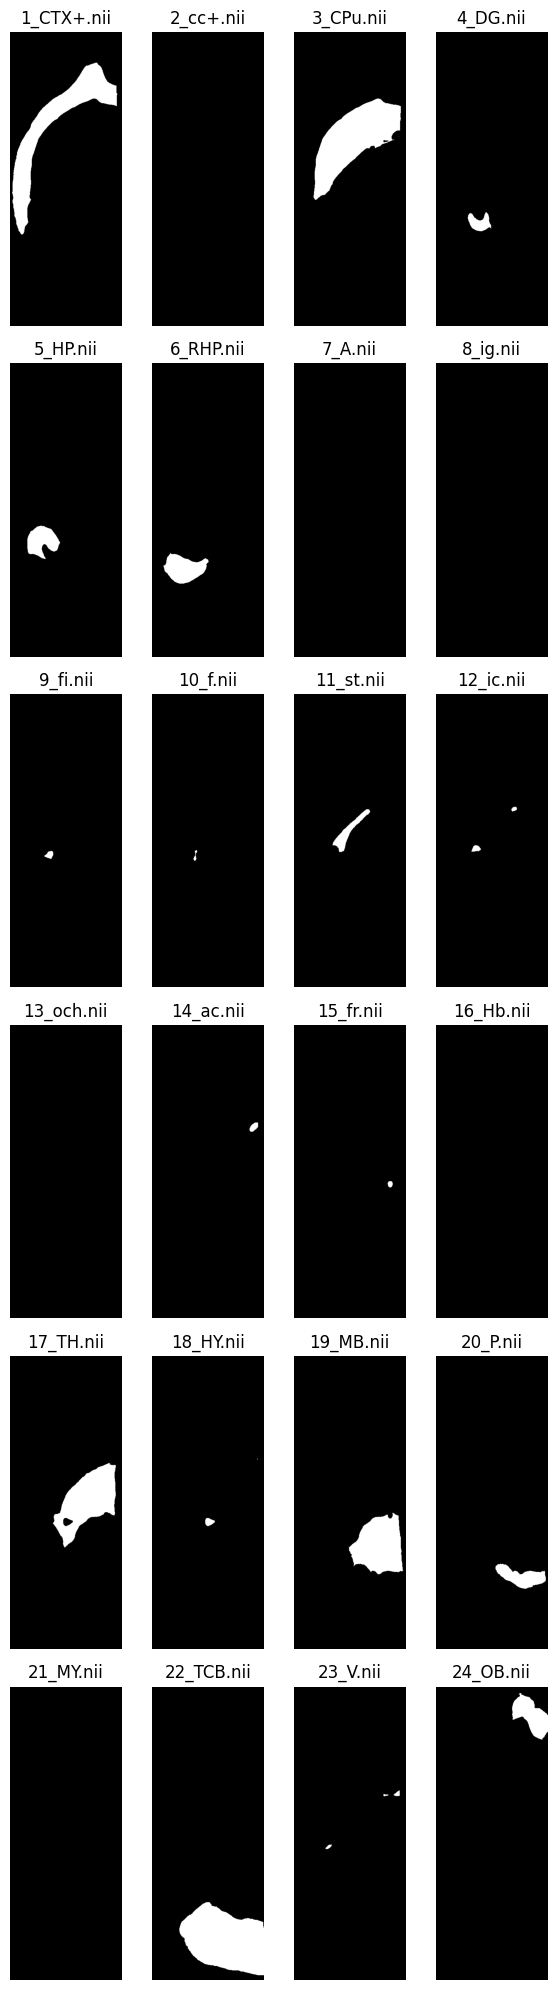

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
import re


# Define the output directory
output_dir = 'dataset/individual_regions/NG4117'

# Get the list of NIfTI files in the directory
nifti_files = [f for f in os.listdir(output_dir) if f.endswith('.nii.gz')]

# Sort the files numerically based on the region number in the filename
nifti_files.sort(key=lambda x: int(re.findall(r'\d+', x)[0]))

# Number of regions
num_regions = len(nifti_files)

# Set the layout for the subplots to 6x4
num_cols = 4
num_rows = 6

# Create a figure with subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6, 20))

# Plot each region
for idx, nifti_file in enumerate(nifti_files):
    # Load the NIfTI file
    img = nib.load(os.path.join(output_dir, nifti_file))
    data = img.get_fdata()
    
    # Extract a middle slice (adjust as needed)
    middle_slice = data[:,:,data.shape[2] // 2]
    # for slice in range(data.shape[2]):
    #     uniq = np.unique(data[:,:,slice])
    #     print(uniq[0])

    #  # Check if the average value of the slice is zero
    # if np.max(middle_slice) == 0:
    #     continue
    
    # Get the corresponding subplot
    ax = axes[idx // num_cols, idx % num_cols]
    
    # Display the slice
    ax.imshow(middle_slice.T, cmap='gray', origin='lower')
    
    # Set the title as the filename without extension
    file_name = os.path.splitext(nifti_file)[0]
    ax.set_title(file_name)
    
    ax.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()